# Digital Information Processing Lab 2025
---
<img align="left" src="https://www.cd.ovgu.de/cd_media/CD_OVGU/Downloads/Logo_jpg_png_svg_EPS_pdf/Logodownload/OVGU_Logo-download-1-p-1950.png" alt="drawing" width="350" />

### &emsp; Class 4: Filters
### &emsp; Group 3 : The Smarties
### &emsp; 17.06.2025


---

Name | Mat. Nr. | Email
--------|---------|---------
Vaibhav Roy| 248956 | vaibhav.roy@st.ovgu.de
Iuliana Belova | 240041 | iuliana.belova@st.ovgu.de
Thejo Prakash Santhana Prasad| 249368 | thejo.santhana@st.ovgu.de

# Class 4: Filters


## Task: Filters

Get Acquainted:

* Familiarize yourself with the various filters and their parameters.

Choose Filters for ECG Signal:

* Select three filters to remove the three types of errors in the ECG signal *ecg_signal_all*.
* Explain which filter is suitable for each type of error and why.
* Set the filter parameters and demonstrate the before and after effects.
* Consider the order in which the filters should be applied.

Visualize the Filtering Process:

* Using the provided plot example, illustrate the filtering process of the ECG signal.
* Write a summary about the process


#Introduction: Parts of the ECG



The electrocardiogram (ECG) is a recording of the electrical activity of the heart. It consists of various components, each representing specific electrical activities of the heart:

* P wave: Shows atrial depolarization (spread of excitation in the atria).
* QRS complex: Shows ventricular depolarization (spread of excitation in the ventricles).
* T wave: Shows ventricular repolarization (recovery of excitation in the ventricles).
* U wave (if present): May represent late repolarization of the Purkinje fibers or other parts of the heart.

Here is an example of a clean ECG signal:



## ECG Generator

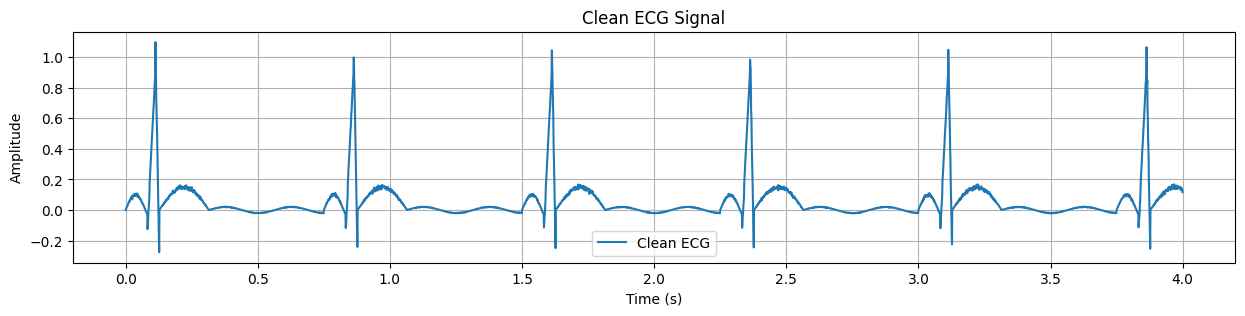

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def single_heartbeat(t, period, amplitude, seed=None):
    if seed is not None:
        np.random.seed(seed)
    amp_adj = 1 * np.random.normal(1, 0.05)
    time_adj1 = 1 * np.random.normal(1, 0.002)
    time_adj2 = 1 * np.random.normal(1, 0.002)
    time_adj3 = 1 * np.random.normal(1, 0.001)

    p_amp = amplitude * 0.1 * amp_adj
    p_wave = p_amp * np.sin(2 * np.pi * (t / period) * 5) * (t <= period * 0.12)

    qrs_start = period * 0.11 * time_adj1
    qrs_peak = period * 0.15 * time_adj2
    qrs_end = period * 0.17 * time_adj3
    qrs_complex = np.piecewise(t,
                               [t < qrs_start,
                                (t >= qrs_start) & (t < qrs_peak),
                                (t >= qrs_peak) & (t <= qrs_end),
                                t > qrs_end],
                               [0,
                                lambda t: amplitude * (-0.1 + (1.0 * (t - qrs_start) / (qrs_peak - qrs_start))),
                                lambda t: amplitude * amp_adj * (1.1 - (1.4 * (t - qrs_peak) / (qrs_end - qrs_peak))),
                                0])

    t_start = period * 0.17
    t_wave = amplitude * 0.15 * amp_adj * (np.sin(2 * np.pi * ((t - t_start) / period) * 2) * ((t >= t_start) & (t <= period * 0.42)))

    u_start = period * 0.42
    u_wave = amplitude * 0.02 * amp_adj * (np.sin(2 * np.pi * ((t - u_start) / period) * 3) * ((t >= u_start) & (t <= period * 1)))

    heartbeat = qrs_complex + p_wave + t_wave + u_wave
    return heartbeat

def generate_ecg_signal(bpm=60, duration=2, sampling_rate=500, amplitude=1):
    num_samples = int(duration * sampling_rate)
    t = np.linspace(0, duration, num_samples, endpoint=False)
    period = 60 / bpm
    ecg_signal = np.array([single_heartbeat(t_i % period, period, amplitude) for t_i in t])
    return t, ecg_signal

# Generate and plot ECG signal
bpm = 80
duration = 4
sampling_rate = 1000

t, ecg_signal = generate_ecg_signal(bpm=bpm, duration=duration, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('Clean ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()





# Introduction of Error Types



There are various types of disturbances that can affect an ECG signal. We will focus on three types:

* Gaussian noise: Random disturbances that make the signal noisy.
* Baseline wander: Slow fluctuations that change the baseline of the signal.
* 50 Hz power line interference: Disturbances from electrical devices that appear as a 50 Hz sine wave.




## Gaussian Noise

Gaussian noise is random disturbances that make the signal noisy.

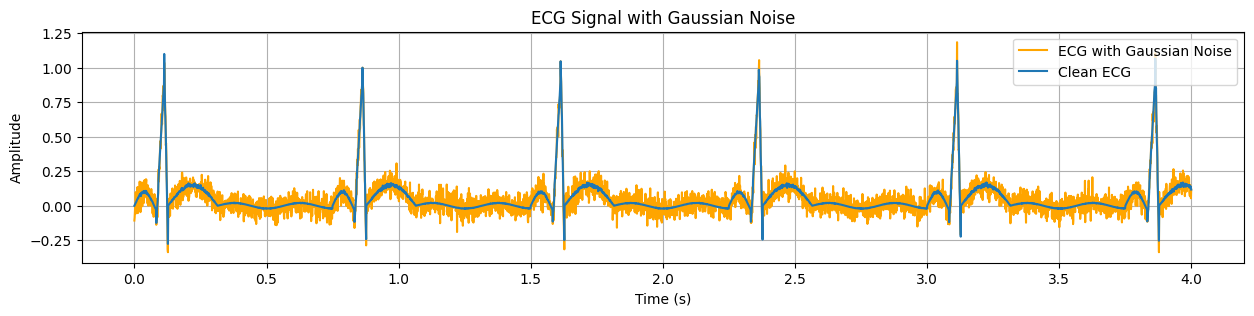

In [31]:
# Function to add Gaussian noise
def add_gaussian_noise(ecg_signal, noise_level=0.01):
    noise = np.random.normal(0, noise_level, len(ecg_signal))
    ecg_signal_noisy = ecg_signal + noise
    return ecg_signal_noisy

# Add Gaussian noise and plot
ecg_signal_gaussian = add_gaussian_noise(ecg_signal, noise_level=0.05)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal_gaussian, label='ECG with Gaussian Noise', color='orange')
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('ECG Signal with Gaussian Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##Baseline Wander

Baseline wander are slow fluctuations that change the baseline of the signal.

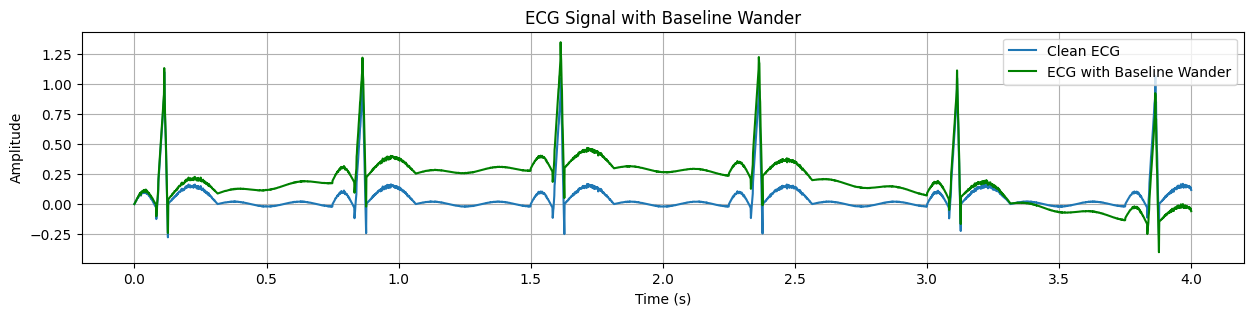

In [32]:
# Function to add baseline wander
def add_baseline_wander(ecg_signal, wander_amplitude=0.1, wander_frequency=0.5, sampling_rate=500):
    t = np.linspace(0, len(ecg_signal) / sampling_rate, len(ecg_signal), endpoint=False)
    baseline_wander = wander_amplitude * np.sin(2 * np.pi * wander_frequency * t)
    ecg_signal_wander = ecg_signal + baseline_wander
    return ecg_signal_wander

# Add baseline wander and plot
ecg_signal_wander = add_baseline_wander(ecg_signal, wander_amplitude=0.3, wander_frequency=0.15, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.plot(t, ecg_signal_wander, label='ECG with Baseline Wander', color='green')
plt.title('ECG Signal with Baseline Wander')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##50 Hz Power Line Interference

Power line interference are disturbances from electrical devices that appear as a 50 Hz sine wave.

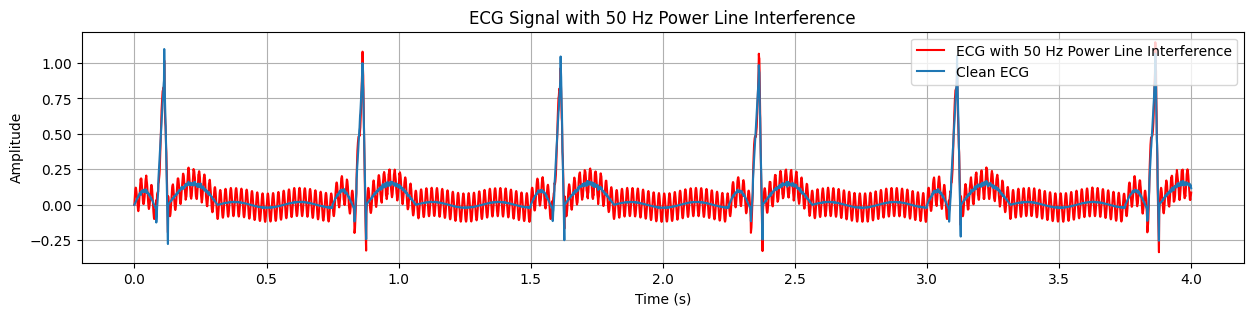

In [33]:
# Function to add 50 Hz power line interference
def add_mains_hum(ecg_signal, hum_frequency=50, hum_amplitude=0.2, sampling_rate=500):
    t = np.linspace(0, len(ecg_signal) / sampling_rate, len(ecg_signal), endpoint=False)
    mains_hum = hum_amplitude * np.sin(2 * np.pi * hum_frequency * t)
    ecg_signal_hum = ecg_signal + mains_hum
    return ecg_signal_hum

# Add power line interference and plot
ecg_signal_hum = add_mains_hum(ecg_signal, hum_amplitude=0.1, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal_hum, label='ECG with 50 Hz Power Line Interference', color='red')
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('ECG Signal with 50 Hz Power Line Interference')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##All Errors Combined

Now all error types will be applied to the clean signal and plotted.

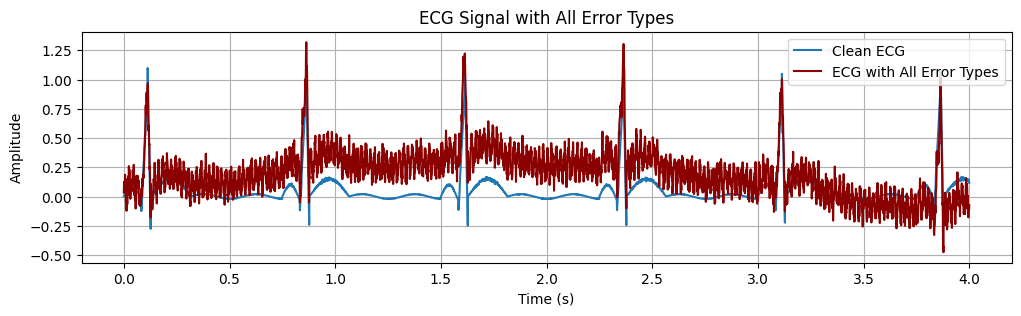

In [34]:
# Add all error types
ecg_signal_all = add_gaussian_noise(ecg_signal, noise_level=0.05)
ecg_signal_all = add_baseline_wander(ecg_signal_all, wander_amplitude=0.3, wander_frequency=0.15, sampling_rate=sampling_rate)
ecg_signal_all = add_mains_hum(ecg_signal_all, hum_amplitude=0.1, sampling_rate=sampling_rate)

# Plot all error types
plt.figure(figsize=(12, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.plot(t, ecg_signal_all, label='ECG with All Error Types', color='darkred')
plt.title('ECG Signal with All Error Types')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### **A short description of Filters**

### High pass filter
In our task high pass filter is used to reduce Baseline wander.

This filter allows the signals with a frequency higher than a certain cutoff frequency to pass through, while reducing the frequencies lower than the cutoff. [<sup>[1]</sup>](#High_pass)

* The filter has a above and below cutoff frequencies $f_c$ .
* Frequencies above $f_c$ pass through mostly unchanged.
* Frequencies below $f_c$ are attenuated (reduced in amplitude).

**Parameters of High Pass Filters**

1. Cutoff Frequency ($f_c$):

  The cutoff frequency of 0.5 Hz is chosen because it slighthly above the baseline wander noise frequency, which is around 0.2 Hz. This enables the high-pass filter to effectively suppress the low-frequency baseline drift while preserving the critical higher-frequency components of the ECG signal.


2. Sampling Frequency ($f_s$):

  The sampling frequency is 500 Hz, means the signal is captured 500 times per second. This rate is high enough to let the high-pass filter work precisely, effectively removing low-frequency noise like baseline wander while keeping the important details of the ECG signal clear and intact.


3. Filter Order:

  We use a 2nd-order high-pass filter because it provides a good balance between complexity and effectiveness in removing noise. This filter sharply attenuates signals below 0.5 Hz, which helps reduce baseline wander noise around 0.2 Hz without distorting important ECG components. The 2nd-order filter effectively cleans the signal while preserving the critical features of the ECG.


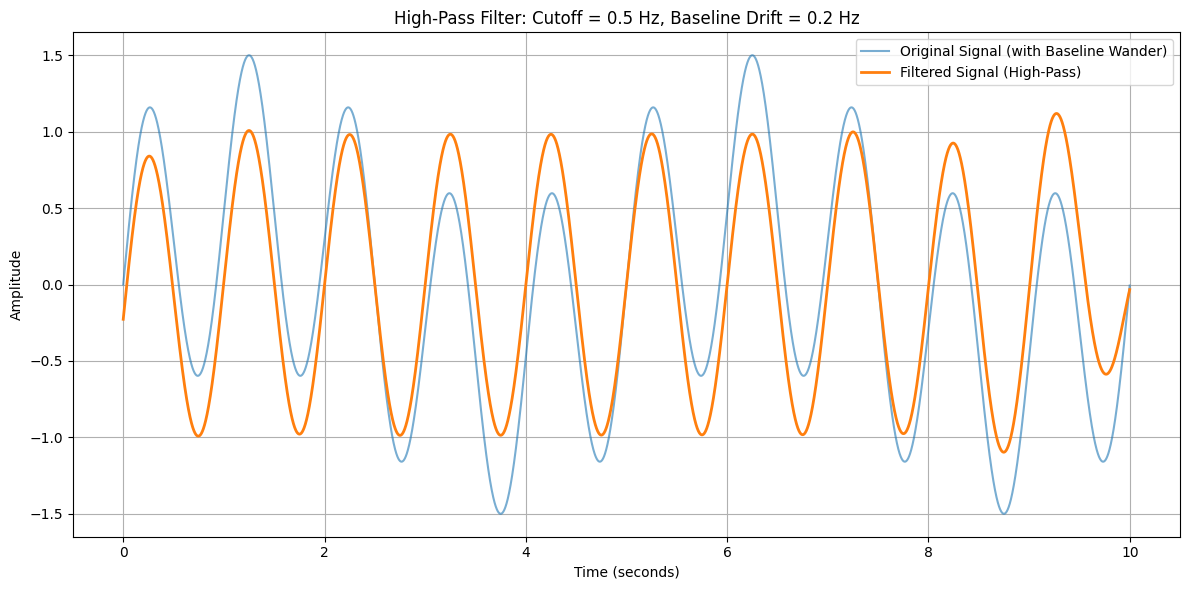

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Filter design parameters ---
cutoff_freq = 0.5       # Cutoff frequency in Hz (high-pass)
sampling_freq = 1000    # Sampling frequency in Hz
filter_order = 3        # Filter order

# --- Design high-pass Butterworth filter ---
def design_highpass_filter(cutoff, fs, order):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

# --- Apply the filter to a signal ---
def apply_filter(signal, b, a):
    return filtfilt(b, a, signal)

# --- Create synthetic ECG-like signal with baseline drift ---
t = np.linspace(0, 10, 10 * sampling_freq, endpoint=False)
baseline_wander = 0.5 * np.sin(2 * np.pi * 0.2 * t)  # Baseline at 0.2 Hz (below cutoff)
ecg_clean = np.sin(2 * np.pi * 1.0 * t)              # Simulated clean ECG at 1 Hz
ecg_signal = ecg_clean + baseline_wander            # ECG with baseline wander

# --- Filter the signal ---
b, a = design_highpass_filter(cutoff_freq, sampling_freq, filter_order)
filtered_signal = apply_filter(ecg_signal, b, a)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(t, ecg_signal, label='Original Signal (with Baseline Wander)', alpha=0.6)
plt.plot(t, filtered_signal, label='Filtered Signal (High-Pass)', linewidth=2)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('High-Pass Filter: Cutoff = 0.5 Hz, Baseline Drift = 0.2 Hz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Low pass filter
In our task low pass filter is used to reduce Muscle Noise.

A low-pass filter is a filter that passes signals with a frequency lower than a selected cutoff frequency and attenuates signals with frequencies higher than the cutoff frequency. The exact frequency response of the filter depends on the filter design. The filter is sometimes called a high-cut filter, or treble-cut filter in audio applications. A low-pass filter is the complement of a high-pass filter. [<sup>[2]</sup>](#Low_pass)

**Parametres of Low Pass filter**
1. cutoff frequency:

   A low-pass filter with a cutoff of 40 Hz is then applied to remove high-frequency noise such as muscle artifacts. This bandpass range of 0.5–40 Hz effectively preserves the key clinical features of the ECG signal (P wave, QRS complex, and T wave) while ensuring the signal is clean and interpretable.

2. Sampling frequency :

  A sampling frequency of 500 Hz provides sufficient temporal resolution for ECG signals, which contain essential information mostly below 40 Hz. With a cutoff of 40 Hz, the low-pass filter effectively removes high-frequency noise such as muscle artifacts, while preserving the critical components of the ECG. The filter’s cutoff is normalized against the Nyquist frequency (250 Hz), ensuring correct digital filter design.
  
3. Filter ordere:

  A 4th-order low-pass filter with a 40 Hz cutoff and 500 Hz sampling rate effectively removes high-frequency noise from the ECG signal. The higher order gives a sharper cutoff, helping to separate noise from important ECG components and ensuring a cleaner, more accurate signal.

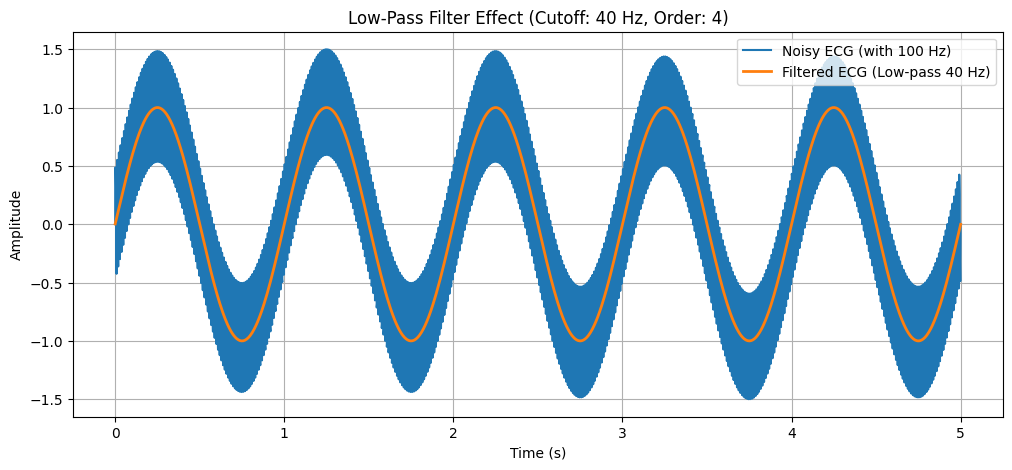

In [36]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 500          # Sampling frequency
fc = 40           # Cutoff frequency
order = 4         # Filter order

# Normalized frequency
Wn = fc / (fs / 2)

# Design Butterworth filter
b, a = butter(order, Wn, btype='low')

# Example signal (replace with your real ECG)
t = np.linspace(0, 5, fs * 5)
ecg_noisy = np.sin(2 * np.pi * 1 * t) + 0.5 * np.sin(2 * np.pi * 100 * t)  # 1 Hz ECG + 100 Hz noise

# Apply filter
ecg_filtered = filtfilt(b, a, ecg_noisy)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(t, ecg_noisy, label="Noisy ECG (with 100 Hz)")
plt.plot(t, ecg_filtered, label="Filtered ECG (Low-pass 40 Hz)", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Low-Pass Filter Effect (Cutoff: 40 Hz, Order: 4)")
plt.legend()
plt.grid()
plt.show()


## Notch filter
In our task Notch filter is used to reduce 50 Hz power line interference.

A notch filter is also known as a band-stop filter. It is a type of filter designed to attenuate or reject a specific frequency or a narrow band of frequencies while allowing other frequencies to pass through unaffected. Notch filters are commonly used in various applications, such as signal processing, audio engineering, and telecommunications, to remove unwanted noise or interference at specific frequencies. [<sup>[3]</sup>](#Notch_filter)

**Parameters of Notch Filters**
1. Sampling frequency:

  The sampling frequency (fs) is set to 500 Hz, meaning the signal is recorded 500 times every second. This sampling rate is sufficient to accurately detect and remove the 50 Hz interference using the notch filter. It provides a clear and detailed representation of the ECG signal while allowing the filter to precisely eliminate powerline noise for better signal quality and analysis.

2. Cutoff frequency:

  The cutoff frequency is set to 50 Hz, matching the frequency of the power line interference. The notch filter is designed to reduce this specific frequency while letting all other frequencies pass through unaffected.

3. Quality Factor:

  The quality factor is set to 30. It determines the bandwidth of the notch filter around the cutoff frequency—higher values mean a narrower bandwidth. This allows the filter to target the 50 Hz noise more precisely while having minimal effect on nearby frequencies.




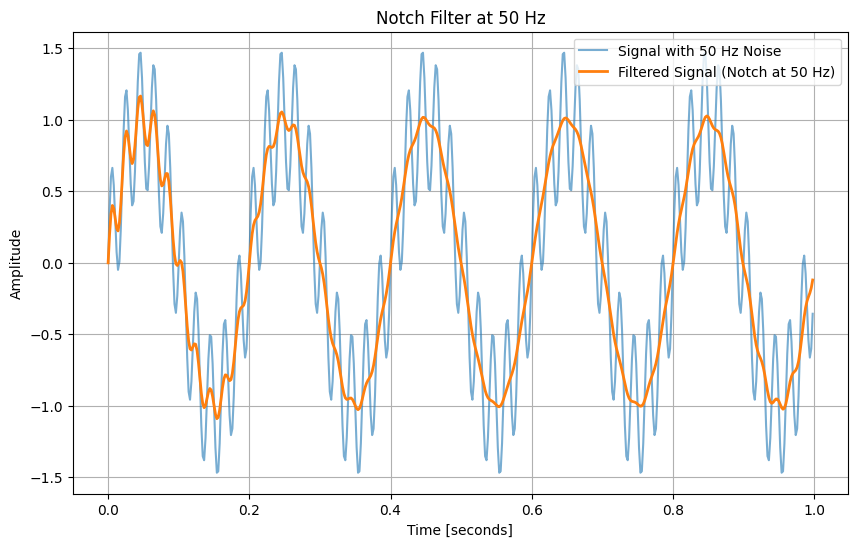

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt

# Parameters
fs = 500       # Sampling frequency (Hz)
f0 = 50           # Frequency to be removed from signal (Hz)
quality_factor = 30  # Quality factor (higher means narrower notch)

# Design notch filter
b, a = iirnotch(f0, quality_factor, fs)

# Example: Generate a test signal with 50 Hz interference
t = np.linspace(0, 1, fs, endpoint=False)
clean_signal = np.sin(2 * np.pi * 5 * t)              # 5 Hz clean signal (simulated ECG component)
noise_50hz = 0.5 * np.sin(2 * np.pi * 50 * t)         # 50 Hz noise
signal_with_noise = clean_signal + noise_50hz

# Apply notch filter
filtered_signal = filtfilt(b, a, signal_with_noise)

# Plot signals
plt.figure(figsize=(10, 6))
plt.plot(t, signal_with_noise, label='Signal with 50 Hz Noise', alpha=0.6)
plt.plot(t, filtered_signal, label='Filtered Signal (Notch at 50 Hz)', linewidth=2)
plt.xlabel('Time [seconds]')
plt.ylabel('Amplitude')
plt.title('Notch Filter at 50 Hz')
plt.legend()
plt.grid(True)
plt.show()


### Wavelet denoising

In our task Wavelet denoising is used to reduce Gaussian Noise.

Wavelet denoising is a signal and image processing technique that reduces noise by transforming data into the wavelet domain, applying thresholding to filter out noise-related coefficients, and then reconstructing the signal or image. Key parameters include the choice of wavelet, thresholding method (hard or soft), and threshold level. [<sup>[4]</sup>](#Wavelet_denoising)

Gaussian noise is random and spread across many frequency components. Wavelet denoising works by selectively reducing these noisy parts while keeping the important details of the signal intact.


### Chossen Settings for Wavelet Denoising

1. Wavelet Selection:
   The db4 wavelet is used because it effectively captures both smooth trends and sharp changes in the signal. This makes it well suited for removing noise while preserving important ECG features.

2. Decomposition Level:

   The signal is decomposed into multiple levels (level 3 in this case), separating it into:

  * Approximation coefficients at the highest level, which capture the overall shape or trend of the signal (low-frequency components).

  * Detail coefficients at each level, which contain the high-frequency components, including noise.

  At level 3, the signal is analyzed at different scales, allowing noise reduction while preserving important ECG features.


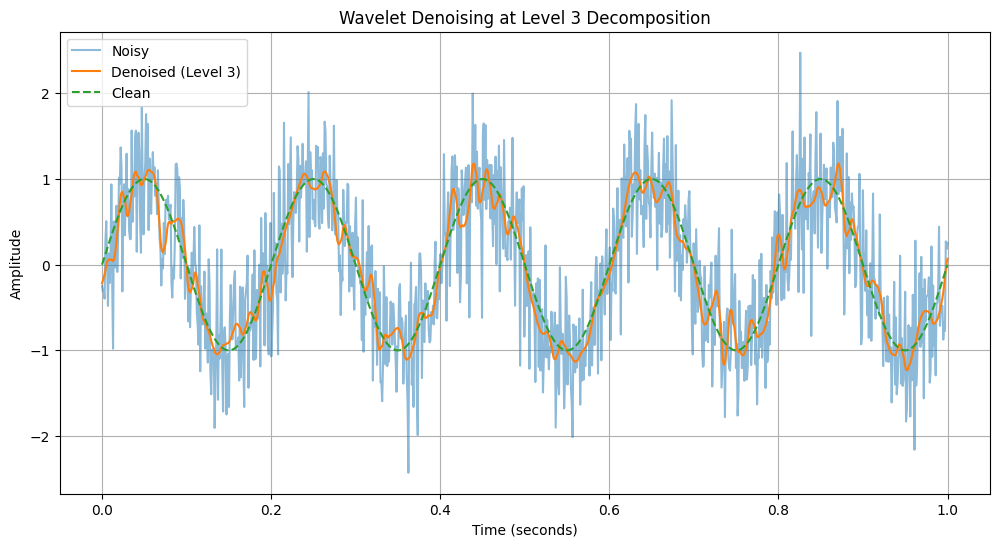

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Wavelet Selection:
#    The db4 wavelet is used because it effectively captures both smooth trends and sharp changes in the signal.
#    This makes it well suited for removing noise while preserving important ECG features.

# 2. Decomposition Level:
#    The signal is decomposed into multiple levels (level 3 in this case), separating it into:

#   * Approximation coefficients at the highest level, which capture the overall shape or trend of the signal (low-frequency components).

#   * Detail coefficients at each level, which contain the high-frequency components, including noise.

#   At level 3, the signal is analyzed at different scales, allowing noise reduction while preserving important ECG features.


fs = 1000
t = np.linspace(0, 1, fs)
clean = np.sin(2 * np.pi * 5 * t)          # Clean signal (5 Hz)
noise = np.random.normal(0, 0.5, fs)       # Random noise
noisy = clean + noise                       # Noisy signal

def denoise(signal, level):
    coeffs = pywt.wavedec(signal, 'db4', level=level)
    threshold = (np.median(np.abs(coeffs[-1])) / 0.6745) * np.sqrt(2 * np.log(len(signal)))
    for i in range(1, len(coeffs)):
        coeffs[i] = pywt.threshold(coeffs[i], threshold, mode='soft')
    return pywt.waverec(coeffs, 'db4')

# Denoise with level 3 decomposition
denoised_level3 = denoise(noisy, level=3)

# Plotting signals with level 3 denoising
plt.figure(figsize=(12, 6))
plt.plot(t, noisy, label='Noisy', alpha=0.5)
plt.plot(t, denoised_level3, label='Denoised (Level 3)')
plt.plot(t, clean, '--', label='Clean')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Wavelet Denoising at Level 3 Decomposition')
plt.legend()
plt.grid(True)
plt.show()



### Savitzky Golay Filter

In our task this filter is used to reduce Gaussian Noise.

This filter is a digital smoothing technique used to reduce noise in a signal without distorting important features like peaks, edges, or slopes. It works by fitting a low-degree polynomial to a sliding window of data points using the least squares method.[<sup>[5]</sup>](#Savitzky_golay_filter)

This filtering process is especially useful for noisy signals like ECGs, because it:

* Smooths out random fluctuations (e.g., Gaussian noise)
* Preserves the original shape and structure of the data
* Is more effective than simple moving averages in retaining fine details

**Chossen setting for Savitzky Golay filter**

1. Window Length:

  A window length of 51 samples at 500 Hz covers about 0.1 seconds, providing enough data to smooth the ECG effectively. It must be odd to properly center the polynomial fit. This size balances noise reduction with preserving important ECG details like sharp QRS complexes.
2. Polynomial Order:

  A 3rd-order polynomial fits each windowed segment, capturing curved shapes like slopes and rounded ECG waves. It preserves important signal details without overfitting to noise.


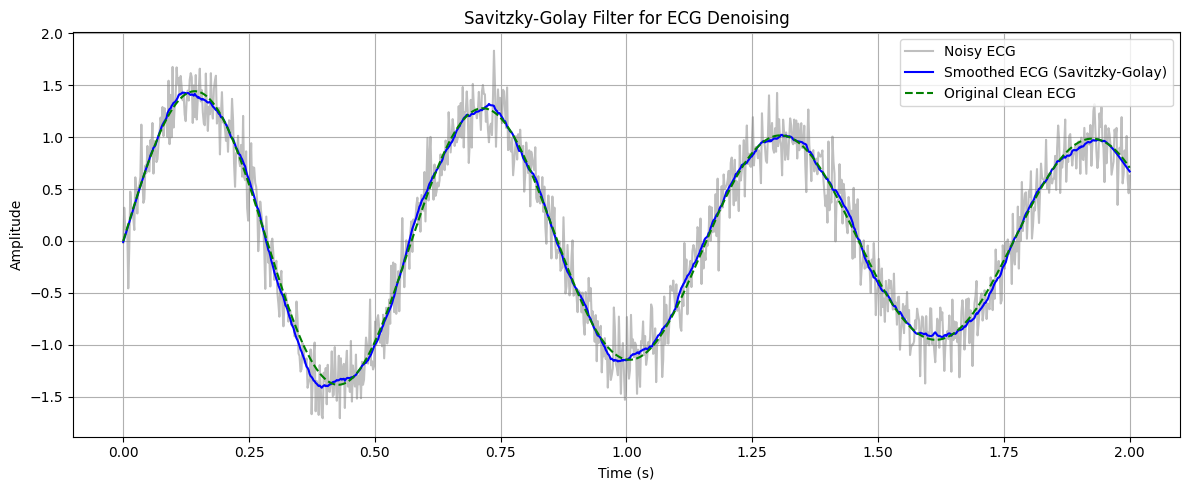

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Simulated noisy ECG signal (or replace with your own)
# Example: a clean ECG waveform with added Gaussian noise
fs = 500  # Sampling frequency (Hz)
t = np.linspace(0, 2, 2 * fs)  # 2 seconds of signal
clean_ecg = 1.2 * np.sin(2 * np.pi * 1.7 * t) + 0.25 * np.sin(2 * np.pi * 2 * t)
noise = 0.2 * np.random.normal(size=len(t))
noisy_ecg = clean_ecg + noise

# Apply Savitzky-Golay Filter
window_length = 51  # Must be odd
polyorder = 3
smoothed_ecg = savgol_filter(noisy_ecg, window_length=window_length, polyorder=polyorder)

# Plotting the result
plt.figure(figsize=(12, 5))
plt.plot(t, noisy_ecg, label='Noisy ECG', alpha=0.5, color='gray')
plt.plot(t, smoothed_ecg, label='Smoothed ECG (Savitzky-Golay)', color='blue')
plt.plot(t, clean_ecg, label='Original Clean ECG', color='green', linestyle='dashed')
plt.title('Savitzky-Golay Filter for ECG Denoising')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Summary
---
**High-Pass Filter for Baseline Wander Removal**

* **Purpose:** Eliminate baseline wander noise (low-frequency drift) in the ECG.
* **Process:** Use a high-pass filter to attenuate low-frequency components, preserving higher frequencies. Proper cutoff frequency, sampling frequency, and filter order ensure baseline wander is removed without significant distortion of the ECG signal.

**Notch Filter for 50 Hz Power Line Interference**

* **Purpose:** Remove 50 Hz power line interference from the ECG signal.
* **Process:** Design the notch filter to reject the 50 Hz frequency precisely, allowing other frequencies to pass. Proper selection of cutoff frequency, sampling frequency, and quality factor ensures effective interference removal without distorting key ECG features.

**Wavelet Denoising for Gaussian Noise Reduction**

* **Purpose:** Reduce Gaussian noise in the ECG signal.
* **Process:** Decompose the signal into frequency components using wavelets, apply thresholding to shrink coefficients below a noise-based threshold, then reconstruct the signal from the denoised coefficients, resulting in a cleaner ECG signal.

**Low pass filter for removing Muscle noise**
* **Purpose:** The low-pass filter removes high-frequency muscle noise in the ECG signal.
* **Process:** The ECG signal, sampled at 500 Hz, is processed with a 4th-order low-pass filter having a 40 Hz cutoff. Normalizing the cutoff against the Nyquist frequency (250 Hz) ensures precise filter design. This filter reduces muscle noise by attenuating frequencies above 40 Hz while preserving key ECG features, producing a cleaner signal for analysis.



**Savitzky Golay Filter for Gaussian Noise Redcution**
* **Purpose:** Reduce Gaussian noise in the ECG signal.
* **Process:** The Savitzky-Golay filter uses a 51-sample window and a 3rd-order polynomial to smooth the ECG signal. This setup effectively reduces noise while preserving important waveform features like the QRS complex by fitting local polynomial curves across the signal.

# **Removing all the noise by using High-pass Filter, Notch Filter and Low-pass Filter.**

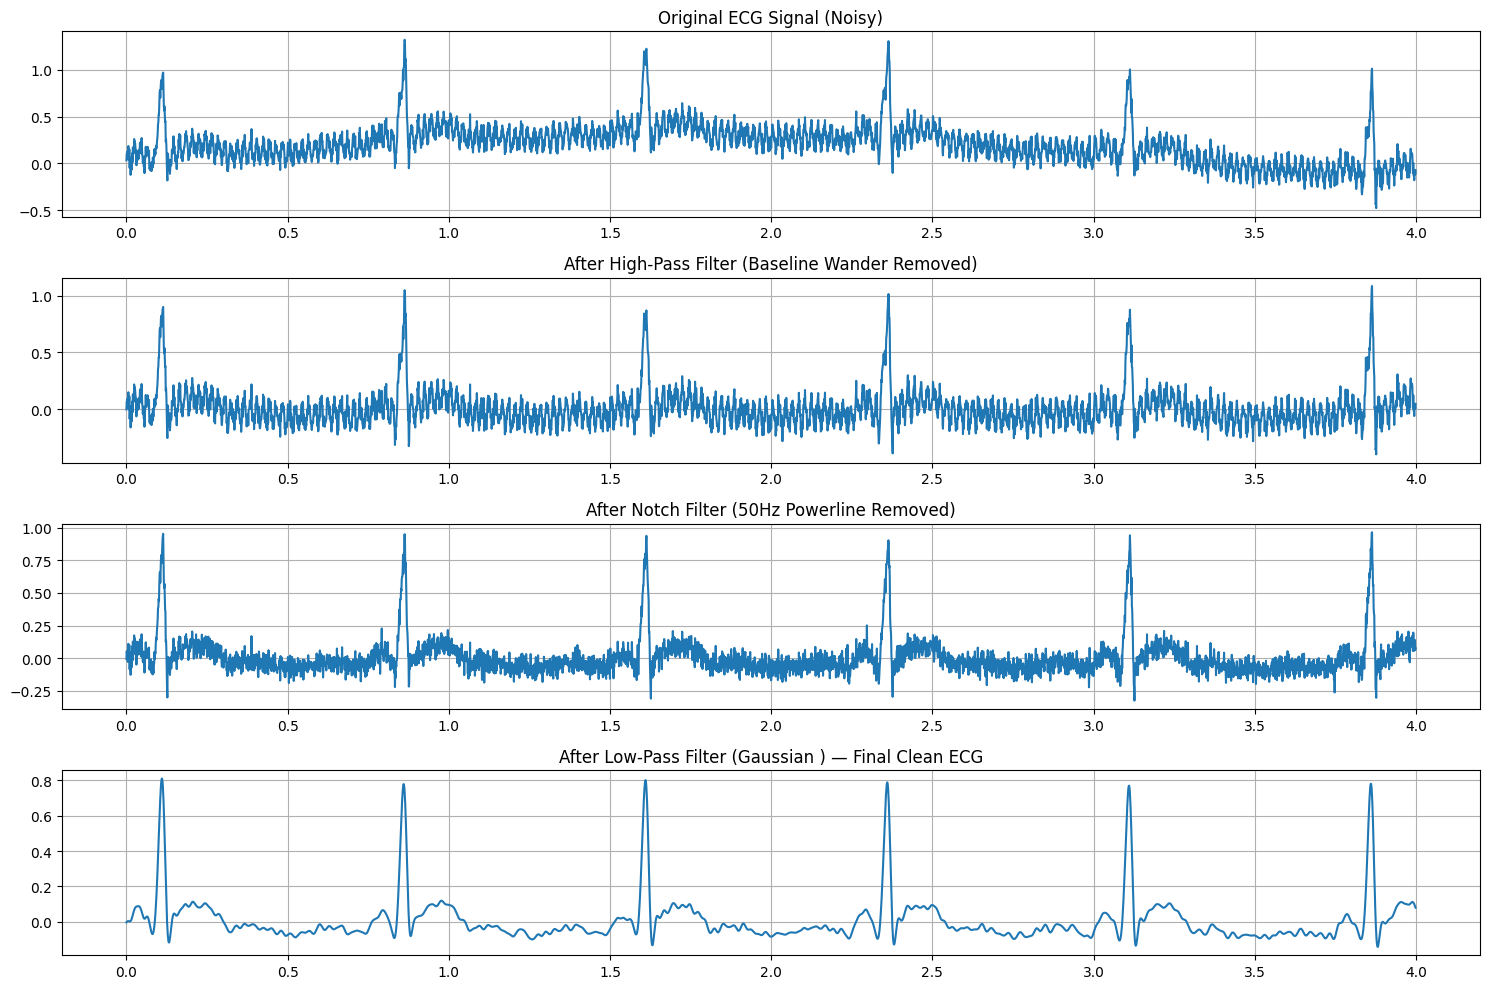

In [40]:
import numpy as np
import matplotlib.pyplot as plt
# Import the necessary functions from scipy.signal
from scipy.signal import butter, filtfilt, iirnotch

# Redefine the filter functions since they were not in the execution scope
def highpass_filter(signal, cutoff=0.5, fs=500, order=2):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal)

def notch_filter(signal, freq=50.0, fs=500, Q=30):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, signal)

def lowpass_filter(signal, cutoff=40, fs=500, order=4):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# Define sampling frequency in Hz. Note: The sampling rate was defined as 1000
# earlier when generating the signal, but the filter functions default to 500.
# Ensure consistency for correct filtering.
fs = sampling_rate # Use the sampling_rate defined earlier for the ECG signal

# Now apply filters
ecg_highpassed = highpass_filter(ecg_signal_all, cutoff=0.5, fs=fs)
ecg_notched = notch_filter(ecg_highpassed, freq=50.0, fs=fs)
ecg_cleaned = lowpass_filter(ecg_notched, cutoff=40, fs=fs)

# Recalculate the time vector 't' to match the length of the filtered signals
t = np.linspace(0, len(ecg_cleaned) / fs, len(ecg_cleaned), endpoint=False)

# Plot results
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(t, ecg_signal_all)
plt.title("Original ECG Signal (Noisy)")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, ecg_highpassed)
plt.title("After High-Pass Filter (Baseline Wander Removed)")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, ecg_notched)
plt.title("After Notch Filter (50Hz Powerline Removed)")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, ecg_cleaned)
plt.title("After Low-Pass Filter (Gaussian ) — Final Clean ECG")
plt.grid()

plt.tight_layout()
plt.show()

# **Removing all the noise by using High-pass Filter, Notch Filter and Wavelet Filter.**

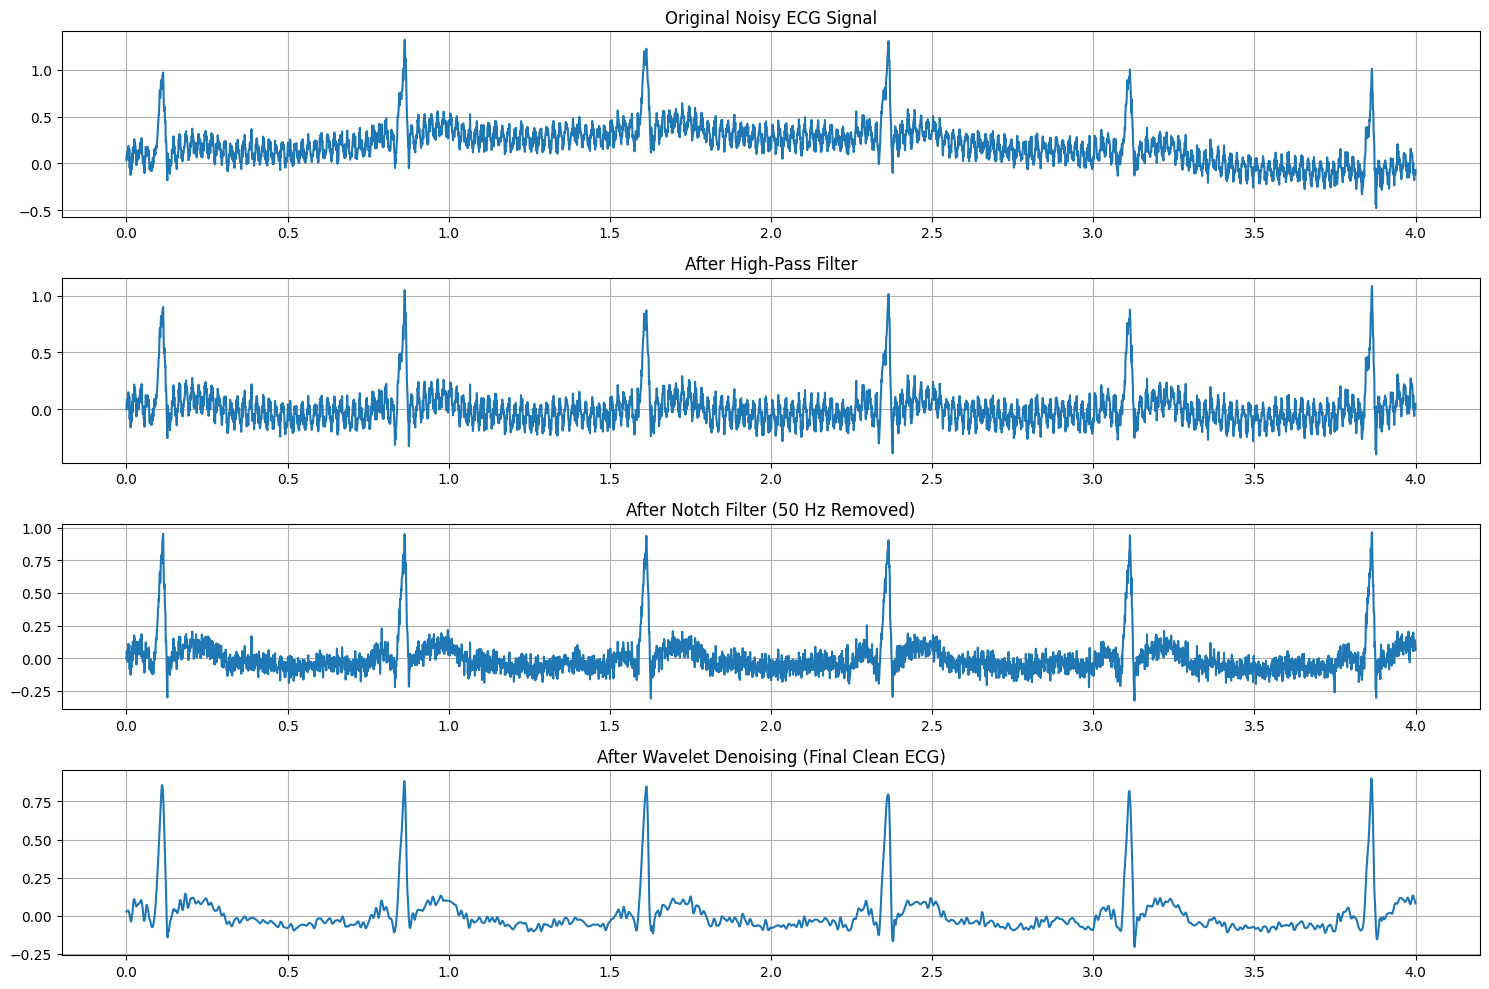

In [41]:
import pywt

# Step 1: Apply High-Pass Filter
ecg_highpassed = highpass_filter(ecg_signal_all, cutoff=0.5, fs=sampling_rate)

# Step 2: Apply Notch Filter
ecg_notched = notch_filter(ecg_highpassed, freq=50.0, fs=sampling_rate)

# Step 3: Apply Wavelet Denoising
def wavelet_denoise(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs_thresh, wavelet)

ecg_final_wavelet = wavelet_denoise(ecg_notched, wavelet='db4', level=3)

# Time axis for plotting
t = np.linspace(0, len(ecg_final_wavelet) / sampling_rate, len(ecg_final_wavelet))

# Plotting stages including wavelet filtered signal
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(t, ecg_signal_all)
plt.title("Original Noisy ECG Signal")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, ecg_highpassed)
plt.title("After High-Pass Filter")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, ecg_notched)
plt.title("After Notch Filter (50 Hz Removed)")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, ecg_final_wavelet)
plt.title("After Wavelet Denoising (Final Clean ECG)")
plt.grid()

plt.tight_layout()
plt.show()


# **Removing all the noise by using High-pass Filter, Notch Filter and Savitzky-Golay Filter.**

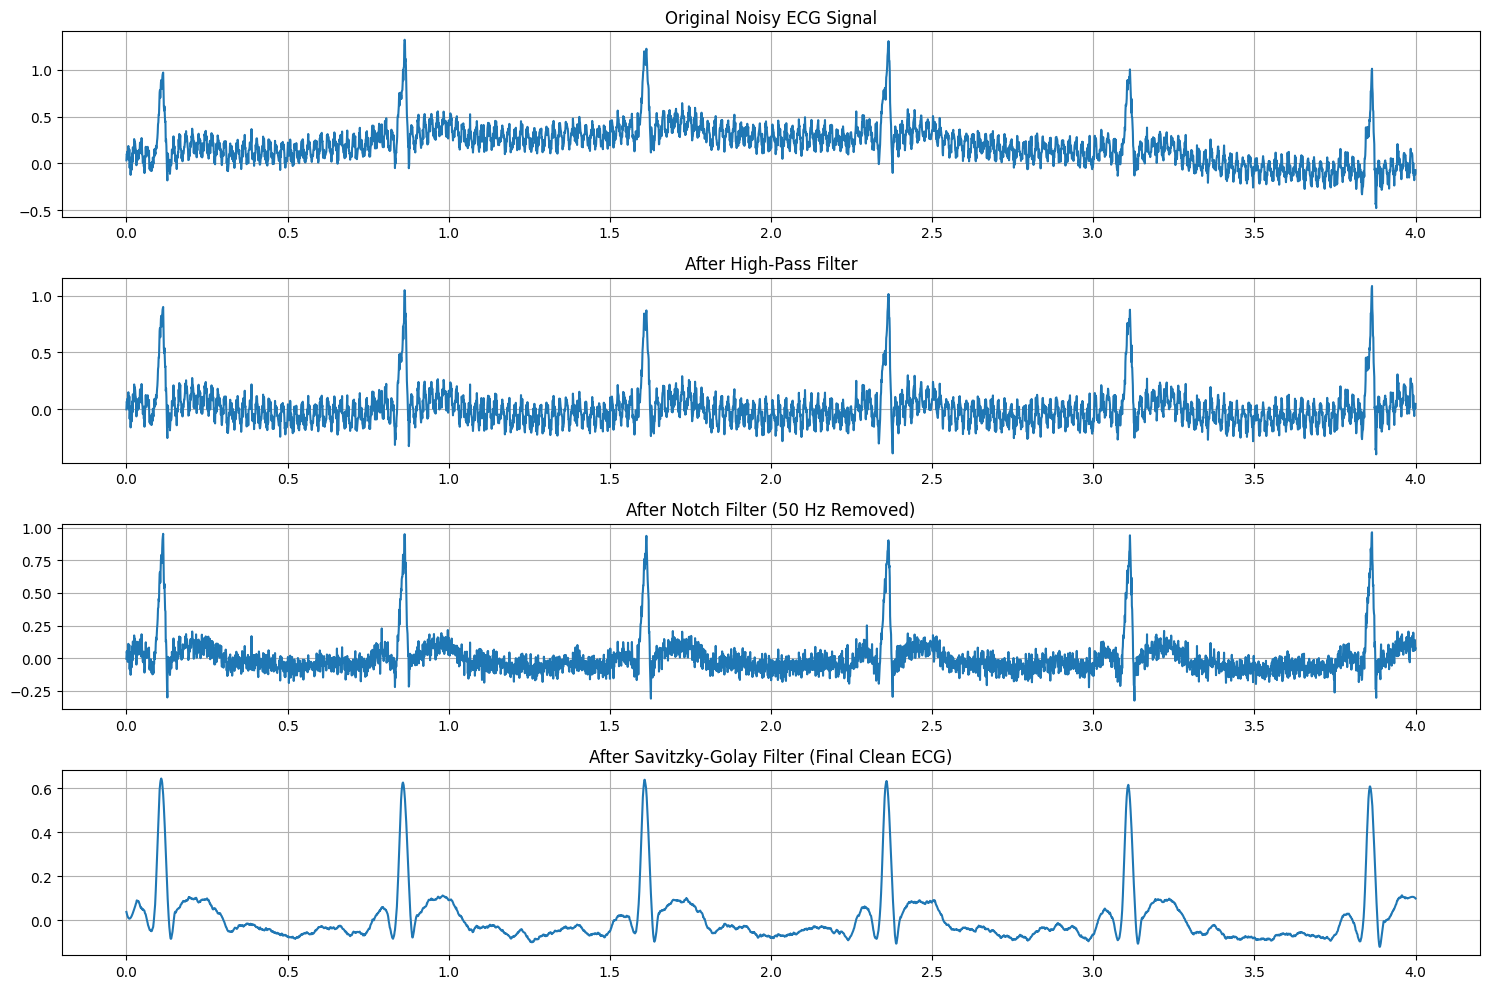

In [42]:
from scipy.signal import savgol_filter

# Step 1: Apply High-Pass Filter
ecg_highpassed = highpass_filter(ecg_signal_all, cutoff=0.5, fs=sampling_rate)

# Step 2: Apply Notch Filter to remove 50 Hz powerline interference
ecg_notched = notch_filter(ecg_highpassed, freq=50.0, fs=sampling_rate)

# Step 3: Apply Savitzky-Golay Filter (smoothing)
# Choose window_length and polyorder appropriate for ECG (window length must be odd)
window_length = 51  # ~0.1 sec window at 500 Hz sampling rate
polyorder = 3
ecg_final_sgolay = savgol_filter(ecg_notched, window_length=window_length, polyorder=polyorder)

# Time axis for plotting
t = np.linspace(0, len(ecg_final_sgolay) / sampling_rate, len(ecg_final_sgolay))

# Plotting all stages
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(t, ecg_signal_all)
plt.title("Original Noisy ECG Signal")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, ecg_highpassed)
plt.title("After High-Pass Filter")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, ecg_notched)
plt.title("After Notch Filter (50 Hz Removed)")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, ecg_final_sgolay)
plt.title("After Savitzky-Golay Filter (Final Clean ECG)")
plt.grid()

plt.tight_layout()
plt.show()


# **Observation of the Signal Changes while using different pairs of Filter.**

**Summary of the Filtering Process**

The goal of this task is to select three filters to remove the three types of errors in the ECG signal such as *baseline wander*, *50 Hz power line interference*, and *Gaussian noise*.
In this Notebook the process was repeated in three variations, each using a different filter for the final stage of noise removal in order to visalize all the results, compare them and make decision which performed better then the others.

**Step-by-Step Explanation and Filter Order**
The order in which the filters are applied is crucial for effective noise removal. The following sequence was used:

**First stage:** *High-Pass Filter* was applied first to eliminate the baseline wander.We know, that baseline wander is a low-frequency noise that causes the baseline of the ECG signal to drift up and down. A high-pass filter allows the higher frequencies of the ECG signal to pass through while blocking the low-frequency drift, effectively centering the signal.

**Second stage:** *Notch Filter* was used to remove the 50 Hz power line interference. This type of noise migh be caused by electrical equipment and manifests as a consistent 50 Hz sine wave superimposed on the ECG signal. The notch filter is designed to specifically target and be capable to remove this narrow frequency band without affecting the rest of the signal.

**Final Stage:** After removing the baseline wander and the 50 Hz interference, a final filter was applied to address the remaining Gaussian noise and other high-frequency noise. Experement was done with three different filters in this final stage such as *Low-pass Filter*, *Wavelet Filter* and *Savitzky-Golay Filter*  leading to the three variations for comparison.

**Observation of Filtering Process**

**First and Second Filtering Stages (High-pass and Notch)**

Before we compare the three variations, it's important to look at the effect of the first two filters, which remain the same for all three methods.

**Performance of High-Pass Filter:** As illustrated in obtained plots, the high-pass filter successfully removes the low-frequency baseline wander. The "Signal after High-pass Filter" plot shows that the ECG signal is now centered around the zero-axis, and the slow drift has been eliminated.

**Performance of Notch Filter:** The subsequent application of the notch filter targets the 50 Hz power line interference. In the "Signal after Notch Filter" plot, we can observe a significant reduction of the amplitude of oscillations, resulting in a much cleaner waveform appearance.

After these two steps, remaining noise is the random, high-frequency Gaussian noise, which each of the three final-stage filters attempts to remove.

**Observation of the Three Filters Performance for the Final Stage**

Here are the detailed observation for each of the three filtering methods used for the Final Stage:

**Method 1:** High-pass Filter, Notch Filter and **Low-pass Filter**

**Perfomance of Low-pass Filter:** The plot, "Signal after Low-pass Filter", illustrates a very smooth-looking signal, indicating that the filter effectively removed the high-frequency Gaussian noise. However, it seems that due to oversmoothing the signal the key features of the ECG are distorted. The R-peak of the QRS complex is noticeably shorter and more rounded than in the other results. Furthermore, the T-wave is significantly flattened, and the sharp definition of the QRS complex is blurred. This confirms that while the low-pass filter removes noise, it also affects the important diagnostic features of the ECG signal.

**Method 2:** High-pass Filter, Notch Filter and **Wavelet Filter**

**Perfomance of Wavelet Filter:** The "Signal after Wavelet Filter" plot illustrates s a very clean signal with minimal residual noise. Most importantly, the morphological features of the ECG are successfully preserved. The QRS complex is sharp and can be precisely identified,due to correct reproduction of its amplitude and duration. The P and T waves are also clear and distinct. This result shows successfull removement of the noise while causing negligible distortion to the underlying signal. We can conclude, this result is the very close to an ideal ECG waveform.

**Method 3:** High-pass Filter,Notch Filter and **Savitzky-Golay Filter**

**Performance of Savitzky-Golay Filter:** The "Signal after Savitzky-Golay Filter" illustrates a significant improvement in comparison with the low-pass filter in terms of key features preservation. The R-peaks are sharper and better preserved, closely reconstructing the amplitude of true ECG signal. This shows the Savitzky-Golay filter's strength in smoothing without severely impacting peak heights. However, the result is not perfect. Some residual noise appears, and the baseline is not as smooth as in the wavelet filter's result. Some minor distortions in the T-wave are also visible. It offers a good balance but doesn't achieve the clarity of the wavelet filter.

**Conclusion**

**The Low-pass filter:** low result, oversmoothing and blurring of the QRS complex and the T-wave.

**The Savitzky-Golay filter:** good result, perfectly preserving the amplitude and shape of the R-peaks and effectively removing noise, but some distortion remains.

**The Wavelet filter:** the most optimal result. It not only removed noise and preserved the QRS complex but also showed the best preservation of the finer details of the signal, such as the P and T waves, and delivered a very smooth baseline.

For the task of reconsrtuction this ECG signal, the "**Method 2**" combination with the Wavelet filter demonstrated the biggest advantage, achieving the best balance between noise removal and the preservation of all diagnostically important morphological features of the signal.

#Reference

<a name="High_pass"></a>

[<sup>[1]</sup>](#High_pass) High Pass Filter, Available at, https://en.wikipedia.org/wiki/High-pass_filter#:~:text=A%20high%2Dpass%20filter%20(HPF,voltages%20or%20radio%20frequency%20devices.

<a name="Low_pass"></a>

[<sup>[2]</sup>](#Low_pass) Loss Pass Filter, Available at, https://en.wikipedia.org/wiki/Low-pass_filter .
<a name="Notch_filter"></a>

[<sup>[3]</sup>](#Notch_filter) Notch filter, Available at, https://www.analog.com/en/resources/glossary/notch-filter.html#:~:text=Definition,of%20center%20frequency%20to%20bandwidth.
<a name="Wavelet_denoising"></a>

[<sup>[4]</sup>](#Wavelet_denoising) Wavelet denoising, Available at, https://link.springer.com/article/10.1007/s44285-024-00025-0#:~:text=The%20wavelet%20based%20method%20effectively,maintaining%20signal%20fidelity%20is%20paramount.
<a name="Savitzky_golay_filter"></a>

[<sup>[5]</sup>](#Savitzky_golay_filter) Savitzky-Golay filter, available at, https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter#:~:text=A%20Savitzky%E2%80%93Golay%20filter%20is,method%20of%20linear%20least%20squares.

In [43]:
######################################################
# "NICE HTML --> PDF Script"
import os
from google.colab import drive, files
drive.mount('/content/gdrive/')

path_to_folder  = '/content/gdrive/MyDrive/Colab Notebooks/'    # <----
filename        = 'Copy of copyofClass_4_group_60'                            # <----
file_path = path_to_folder + filename + '.ipynb'
html_path = path_to_folder + filename + '.html'
!jupyter nbconvert --to html "{file_path}"
files.download(html_path)
######################################################

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
[NbConvertApp] Converting notebook /content/gdrive/MyDrive/Colab Notebooks/Copy of copyofClass_4_group_60.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 2581951 bytes to /content/gdrive/MyDrive/Colab Notebooks/Copy of copyofClass_4_group_60.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>